In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Cek data
print("Shape:", df.shape)
print("\nKolom:", df.columns.tolist())
df.head()

Shape: (9994, 21)

Kolom: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Cek tipe data & missing values
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [4]:
# Ubah Order Date ke format tanggal
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
print("Tahun tersedia:", df['Year'].unique())

Tahun tersedia: [2016 2015 2014 2017]


ValueError: 'blues_d' is not a valid palette name

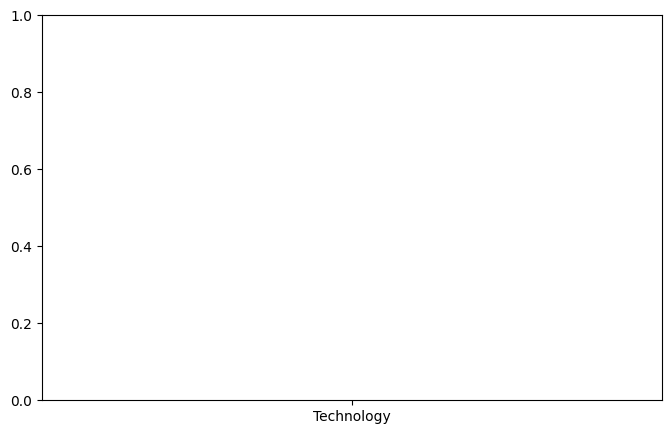

In [6]:
# Total penjualan per kategori
sales_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=sales_category, x='Category', y='Sales', hue='Category', palette='blues_d', legend=False)
plt.title('Total Penjualan per Kategori Produk', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Total Sales (USD)')
plt.tight_layout()
plt.show()


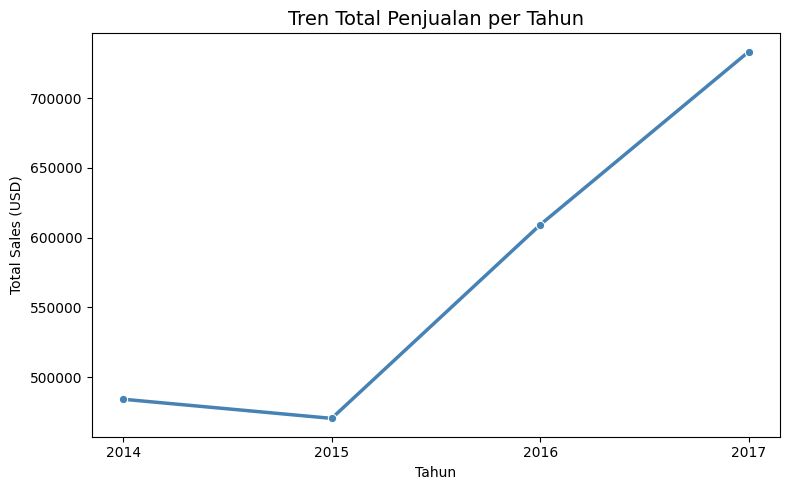

In [8]:
# Tren penjualan per tahun
sales_year = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=sales_year, x='Year', y='Sales', marker='o', linewidth=2.5, color='steelblue')
plt.title('Tren Total Penjualan per Tahun', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Total Sales (USD)')
plt.xticks(sales_year['Year'])
plt.tight_layout()
plt.show()

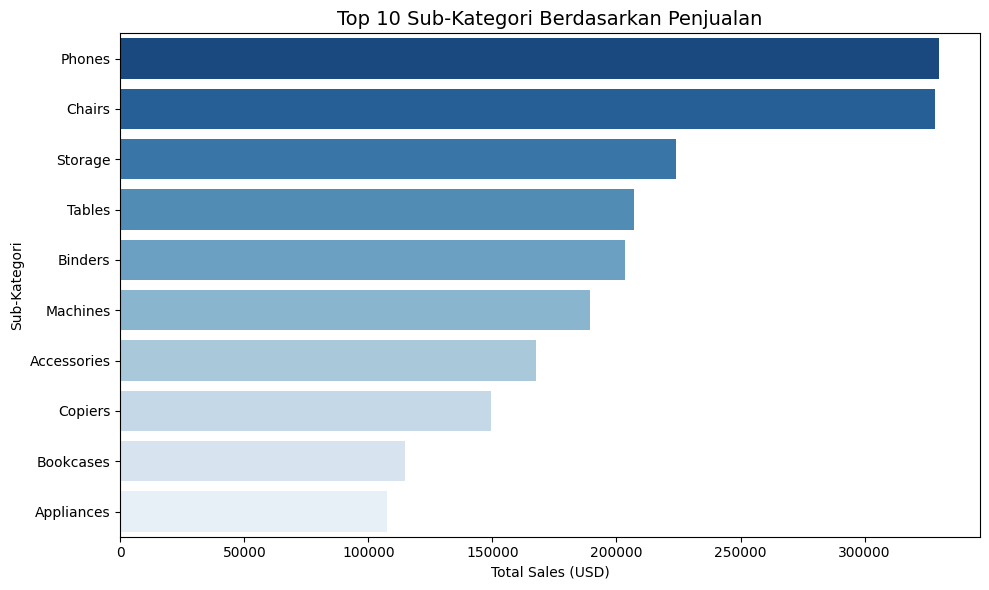

In [9]:
# Top 10 sub-kategori
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_sub, x='Sales', y='Sub-Category', hue='Sub-Category', palette='Blues_r', legend=False)
plt.title('Top 10 Sub-Kategori Berdasarkan Penjualan', fontsize=14)
plt.xlabel('Total Sales (USD)')
plt.ylabel('Sub-Kategori')
plt.tight_layout()
plt.show()

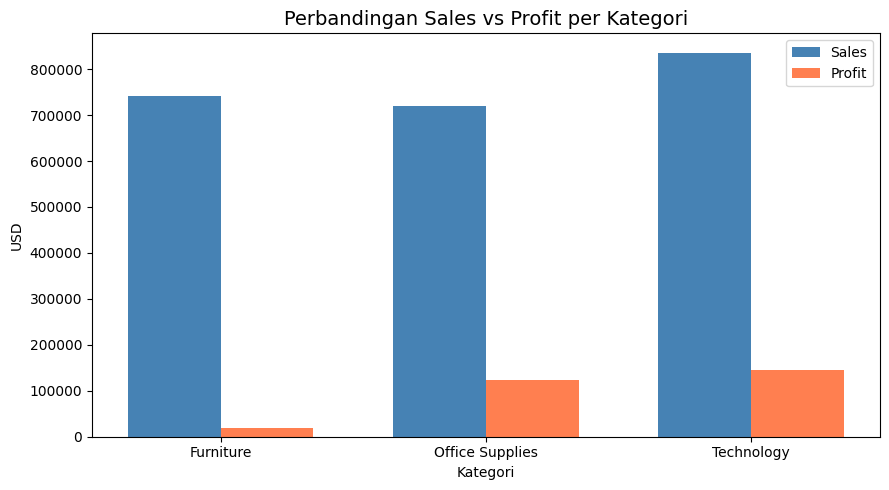

In [10]:
# Perbandingan Sales vs Profit per Kategori
profit_cat = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

x = range(len(profit_cat['Category']))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], profit_cat['Sales'], width, label='Sales', color='steelblue')
ax.bar([i + width/2 for i in x], profit_cat['Profit'], width, label='Profit', color='coral')

ax.set_title('Perbandingan Sales vs Profit per Kategori', fontsize=14)
ax.set_xlabel('Kategori')
ax.set_ylabel('USD')
ax.set_xticks(x)
ax.set_xticklabels(profit_cat['Category'])
ax.legend()
plt.tight_layout()
plt.show()

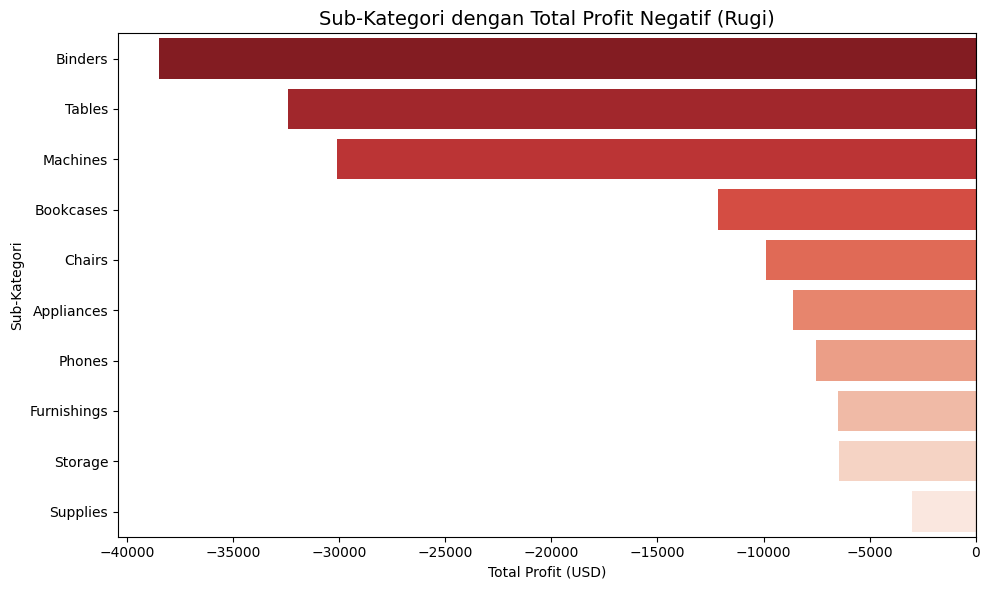

In [11]:
# Produk yang merugi
rugi = df[df['Profit'] < 0].groupby('Sub-Category')['Profit'].sum().sort_values().head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=rugi, x='Profit', y='Sub-Category', hue='Sub-Category', palette='Reds_r', legend=False)
plt.title('Sub-Kategori dengan Total Profit Negatif (Rugi)', fontsize=14)
plt.xlabel('Total Profit (USD)')
plt.ylabel('Sub-Kategori')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [12]:
# Export ringkasan ke CSV
summary = df.groupby('Category')[['Sales', 'Profit', 'Quantity']].sum().reset_index()
summary['Profit_Margin_%'] = (summary['Profit'] / summary['Sales'] * 100).round(2)
print(summary)
summary.to_csv('ringkasan_kategori.csv', index=False)
print("\n✅ File ringkasan_kategori.csv berhasil disimpan!")

          Category        Sales       Profit  Quantity  Profit_Margin_%
0        Furniture  741999.7953   18451.2728      8028             2.49
1  Office Supplies  719047.0320  122490.8008     22906            17.04
2       Technology  836154.0330  145454.9481      6939            17.40

✅ File ringkasan_kategori.csv berhasil disimpan!
